In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving laptop_price - dataset.csv to laptop_price - dataset.csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['laptop_price - dataset.csv']))
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [ ]:
df.describe()

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,2.302980,8.440784,2.040525,1134.969059
std,1.429470,0.503846,5.097809,0.669196,700.752504
min,10.100000,0.900000,2.000000,0.690000,174.000000
25%,14.000000,2.000000,4.000000,1.500000,609.000000
50%,15.600000,2.500000,8.000000,2.040000,989.000000
75%,15.600000,2.700000,8.000000,2.310000,1496.500000
max,18.400000,3.600000,64.000000,4.700000,6099.000000


In [ ]:
df.isnull().sum()

,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
CPU_Company,0
CPU_Type,0
CPU_Frequency (GHz),0
RAM (GB),0
Memory,0


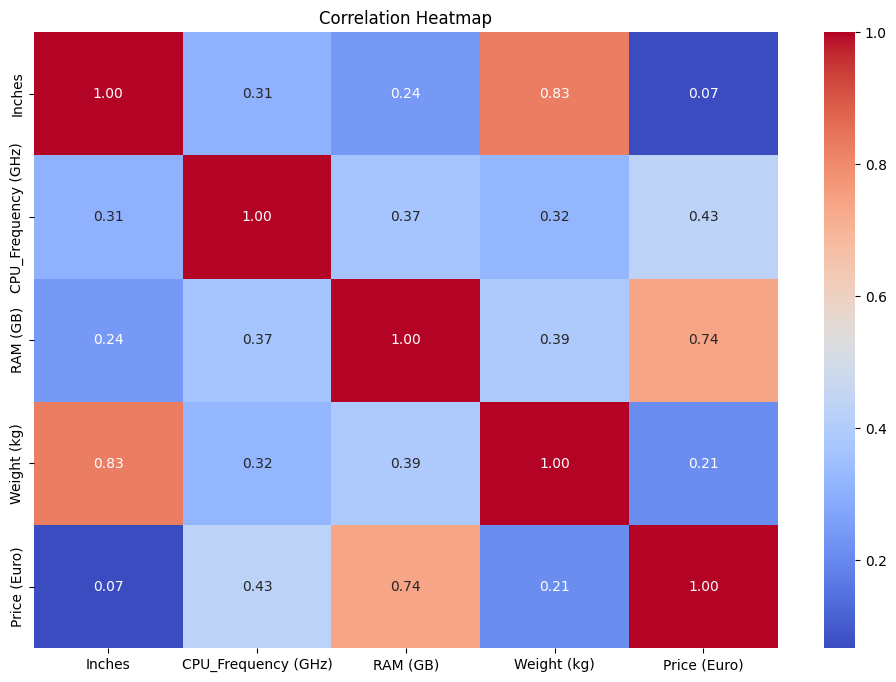

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

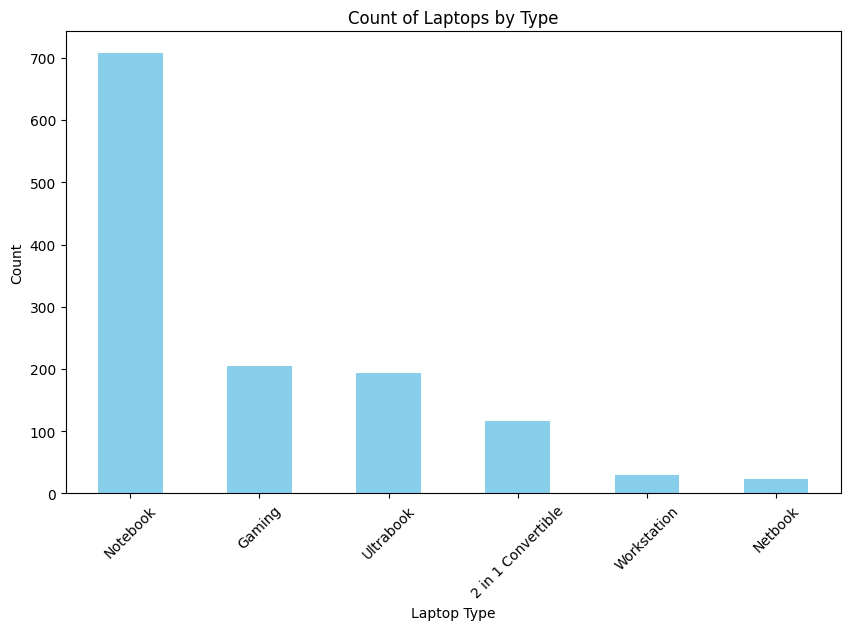

In [ ]:
plt.figure(figsize=(10,6))
df['TypeName'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Count of Laptops by Type')
plt.xlabel('Laptop Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

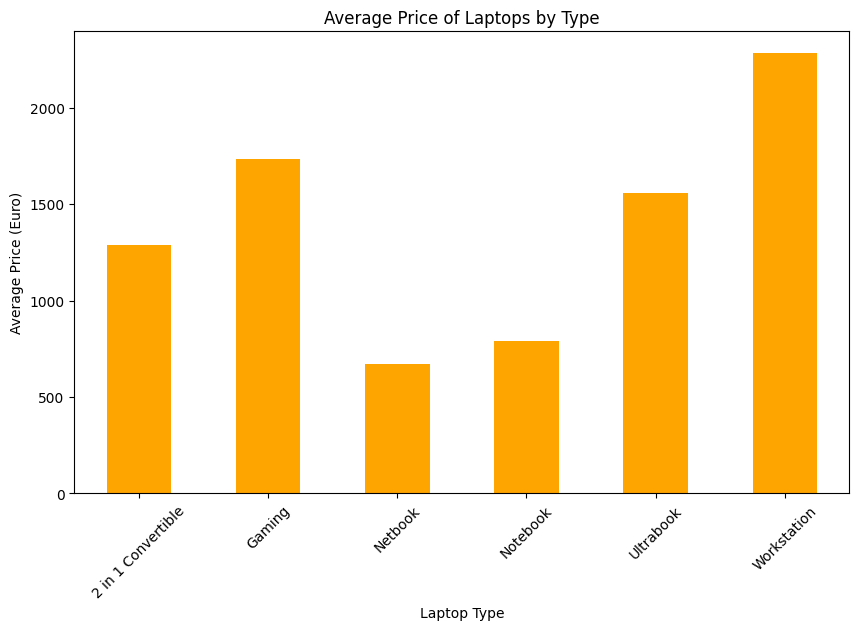

In [ ]:
plt.figure(figsize=(10,6))
df.groupby('TypeName')['Price (Euro)'].mean().plot(kind='bar', color='orange')
plt.title('Average Price of Laptops by Type')
plt.xlabel('Laptop Type')
plt.ylabel('Average Price (Euro)')
plt.xticks(rotation=45)
plt.show()

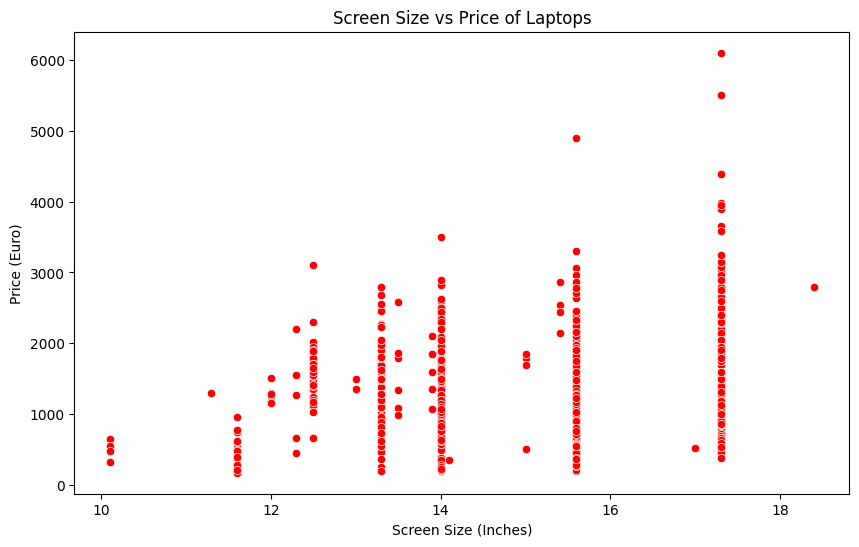

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Inches', y='Price (Euro)', data=df, color='red')
plt.title('Screen Size vs Price of Laptops')
plt.xlabel('Screen Size (Inches)')
plt.ylabel('Price (Euro)')
plt.show()

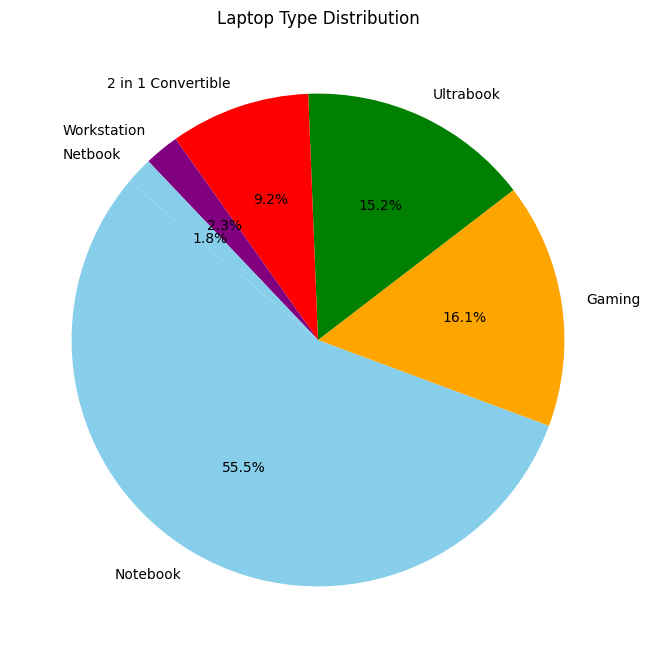

In [ ]:
plt.figure(figsize=(8, 8))
type_counts = df['TypeName'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.title('Laptop Type Distribution')
plt.show()

In [20]:
numerical_cols = ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'Price (Euro)']

for col in numerical_cols:
    print(f"{col}: Mean={df[col].mean():.2f}, Median={df[col].median():.2f}, Var={df[col].var():.2f}, Std={df[col].std():.2f}")


Inches: Mean=15.02, Median=15.60, Var=2.04, Std=1.43
CPU_Frequency (GHz): Mean=2.30, Median=2.50, Var=0.25, Std=0.50
RAM (GB): Mean=8.44, Median=8.00, Var=25.99, Std=5.10
Weight (kg): Mean=2.04, Median=2.04, Var=0.45, Std=0.67
Price (Euro): Mean=1134.97, Median=989.00, Var=491054.07, Std=700.75


In [ ]:
from sklearn.preprocessing import LabelEncoder
categorical_columns = ['Company', 'Product', 'TypeName', 'ScreenResolution',
                       'CPU_Company', 'CPU_Type', 'Memory',
                       'GPU_Company', 'GPU_Type', 'OpSys']

le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,300,4,13.3,23,1,40,2.3,8,4,2,56,8,1.37,1339.69
1,1,301,4,13.3,1,1,40,1.8,8,2,2,50,8,1.34,898.94
2,7,50,3,15.6,8,1,46,2.5,8,16,2,52,4,1.86,575.00
3,1,300,4,15.4,25,1,54,2.7,16,29,0,76,8,1.83,2537.45
4,1,300,4,13.3,23,1,40,3.1,8,16,2,57,8,1.37,1803.60
